# NLP Final Exam — Custom Project: AI-Powered Bouquet Composition

**Course:** Natural Language Processing  
**Option:** II — Custom Project     
**Student_name:** Aldanayev Assylkhan

---

## Problem

Given a natural-language description of a desired bouquet (in Russian), a budget in KZT,
and preferred colour palette, **select a subset of in-stock flowers** that is aesthetically
coherent and budget-compliant.

This is a structured NLP generation task: the model must interpret free-form human language
and produce a structured JSON artefact encoding floristry aesthetics, colour relationships,
and budget reasoning.

## Methodology

I use **Meta Llama 3.1 8B** served locally via **Ollama** (OpenAI-compatible API at
`http://localhost:11434/v1`). The model receives:

- The client’s request (Russian natural language)
- Budget bounds: lower 60% / upper 140% of the stated budget  
- A catalogue of available flowers (name, colour tags, price per stem, stock quantity)

The model responds with a JSON object listing flower IDs, quantities, style modifiers,
and a Russian-language explanation.

**JSON reliability strategy:** Open-weight models do not reliably honour
`response_format=json_object`. We inject a JSON-only instruction into the system prompt
and apply two-stage parsing: direct `json.loads()` → regex extraction `{[\s\S]*}` →
`LLMError` if both fail.

## Evaluation

12 test cases: **4 budget levels** (5 000 / 10 000 / 20 000 / 30 000 KZT) ×
**3 Russian prompts**.

| Metric | Definition |
|--------|----------|
| **Budget compliance rate** | % where total cost ∈ [budget × 0.60, budget × 1.40] |
| **JSON reliability** | Distribution: clean parse / regex-recovered / failed |
| **Response latency** | Seconds per request, grouped by budget |


In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'openai', 'pandas', 'matplotlib', 'nest_asyncio'],
    check=True, capture_output=True,
)
print('Dependencies ready.')


Dependencies ready.


In [2]:
import asyncio
import json
import re
import time

import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
from openai import AsyncOpenAI

nest_asyncio.apply()  # allow asyncio.run() inside Jupyter's event loop

OLLAMA_BASE_URL = 'http://localhost:11434/v1'
OLLAMA_MODEL    = 'llama3.1:8b'
BUDGET_LOWER    = 0.600   # same as backend ai_config_defaults.py
BUDGET_UPPER    = 1.400
print(f'Ollama endpoint: {OLLAMA_BASE_URL}  model: {OLLAMA_MODEL}')


Ollama endpoint: http://localhost:11434/v1  model: llama3.1:8b


In [3]:
# Representative subset of Bouquet AI Platform seed data (backend/app/services/seed_service.py)
FLOWERS = [
    {'id': 'f001', 'name': 'Роза Pink O\'Hara',         'color_tags': ['pink'],            'price_kzt': 1100, 'stock_qty': 32},
    {'id': 'f002', 'name': 'Пион Sarah Bernhardt',      'color_tags': ['pink', 'white'],   'price_kzt': 1900, 'stock_qty': 18},
    {'id': 'f003', 'name': 'Эустома белая',             'color_tags': ['white'],           'price_kzt':  850, 'stock_qty': 24},
    {'id': 'f004', 'name': 'Гипсофила',                 'color_tags': ['white'],           'price_kzt':  420, 'stock_qty': 60},
    {'id': 'f005', 'name': 'Ранункулюс',                'color_tags': ['yellow', 'white'], 'price_kzt':  980, 'stock_qty': 28},
    {'id': 'f006', 'name': 'Эвкалипт Cinerea',          'color_tags': ['green'],           'price_kzt':  540, 'stock_qty': 45},
    {'id': 'f007', 'name': 'Тюльпан French',            'color_tags': ['red', 'yellow'],   'price_kzt':  760, 'stock_qty': 35},
    {'id': 'f008', 'name': 'Роза Quicksand',            'color_tags': ['pink'],            'price_kzt': 1250, 'stock_qty': 40},
    {'id': 'f009', 'name': 'Гортензия',                 'color_tags': ['blue', 'white'],   'price_kzt': 2100, 'stock_qty': 12},
    {'id': 'f010', 'name': 'Лизиантус',                 'color_tags': ['purple', 'white'], 'price_kzt':  920, 'stock_qty': 26},
    {'id': 'f011', 'name': 'Каллы',                     'color_tags': ['white'],           'price_kzt': 1340, 'stock_qty': 18},
    {'id': 'f012', 'name': 'Анемоны',                   'color_tags': ['red', 'purple'],   'price_kzt': 1100, 'stock_qty': 22},
    {'id': 'f013', 'name': 'Питтоспорум',               'color_tags': ['green'],           'price_kzt':  380, 'stock_qty': 50},
    {'id': 'f014', 'name': 'Роза Mondial',              'color_tags': ['white'],           'price_kzt':  980, 'stock_qty': 50},
    {'id': 'f015', 'name': 'Хризантема Pina Colada',    'color_tags': ['white', 'yellow'], 'price_kzt':  740, 'stock_qty': 30},
    {'id': 'f016', 'name': 'Маттиола',                  'color_tags': ['purple', 'white'], 'price_kzt':  880, 'stock_qty': 28},
    {'id': 'f017', 'name': 'Ирис голубой',              'color_tags': ['blue'],            'price_kzt':  580, 'stock_qty': 24},
    {'id': 'f018', 'name': 'Гербера оранж',             'color_tags': ['orange'],          'price_kzt':  480, 'stock_qty': 40},
]
print(f'Catalogue: {len(FLOWERS)} flowers loaded')


Catalogue: 18 flowers loaded


In [4]:
_JSON_RE = re.compile(r'{[\s\S]*}', re.MULTILINE)

SYSTEM_PROMPT = (
    'Ты - флорист-консультант. Правила: '
    '1. Используй только flower_id из склада. '
    '2. quantity не превышает stock. '
    '3. Сумма в диапазоне [budget_min_kzt, budget_max_kzt]. '
    '4. 3-6 уникальных цветов, мин. 12 стеблей. '
    '5. Хотя бы у одного цветка quantity >= 5. '
    '6. style_modifiers - 1-3 английских фразы. '
    '7. explanation - на русском, 1-2 предложения. '
    'Ответ строго в JSON: '
    '{composition:[{flower_id:f001,quantity:7}],style_modifiers:[lush],explanation:...} '
    'You MUST respond with valid JSON only. No explanation, no markdown, no commentary.'
)


class LLMError(Exception):
    pass


class OllamaLLMClient:
    def __init__(self, base_url: str, model: str):
        self._client = AsyncOpenAI(base_url=base_url, api_key='none', timeout=120)
        self._model  = model

    async def select_composition(self, prompt, preferred_colors, budget, available_flowers):
        payload = {
            'client_request':   prompt,
            'preferred_colors': preferred_colors,
            'budget_kzt':       budget,
            'budget_min_kzt':   round(budget * BUDGET_LOWER, 2),
            'budget_max_kzt':   round(budget * BUDGET_UPPER, 2),
            'available_flowers': [
                {
                    'flower_id':      f['id'],
                    'name':           f['name'],
                    'color_tags':     f['color_tags'],
                    'price_per_stem': f['price_kzt'],
                    'stock':          f['stock_qty'],
                }
                for f in available_flowers
            ],
        }
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': json.dumps(payload, ensure_ascii=False)},
        ]
        try:
            resp = await self._client.chat.completions.create(
                model=self._model, messages=messages, temperature=0.7, stream=False,
            )
        except Exception as exc:
            raise LLMError(f'API call failed: {exc}') from exc

        text = (resp.choices[0].message.content or '').strip()
        try:
            return json.loads(text), 'clean'
        except json.JSONDecodeError:
            pass
        m = _JSON_RE.search(text)
        if m:
            try:
                return json.loads(m.group()), 'regex'
            except json.JSONDecodeError:
                pass
        raise LLMError(f'Non-JSON response: {text[:200]}')


print('OllamaLLMClient ready.')


OllamaLLMClient ready.


In [5]:
TEST_CASES = [
    {'prompt': 'Нежный букет для мамы на день рождения',     'colors': ['pink', 'white']},
    {'prompt': 'Яркий свадебный букет в красно-белых тонах', 'colors': ['red', 'white']},
    {'prompt': 'Скромный букет для подруги с белыми цветами', 'colors': ['white']},
]
BUDGETS = [5_000, 10_000, 20_000, 30_000]


async def run_tests():
    client    = OllamaLLMClient(OLLAMA_BASE_URL, OLLAMA_MODEL)
    price_map = {f['id']: f['price_kzt'] for f in FLOWERS}
    rows      = []
    total     = len(BUDGETS) * len(TEST_CASES)
    done      = 0
    for budget in BUDGETS:
        for tc in TEST_CASES:
            done += 1
            print(f'[{done:>2}/{total}] budget={budget:>6,}  {tc["prompt"][:45]}...')
            t0 = time.perf_counter()
            try:
                comp, stage = await client.select_composition(
                    prompt=tc['prompt'],
                    preferred_colors=tc['colors'],
                    budget=float(budget),
                    available_flowers=FLOWERS,
                )
                dur = round(time.perf_counter() - t0, 1)
                total_cost = sum(
                    price_map.get(item['flower_id'], 0) * item['quantity']
                    for item in comp.get('composition', [])
                )
                compliant = budget * BUDGET_LOWER <= total_cost <= budget * BUDGET_UPPER
                rows.append({
                    'prompt':           tc['prompt'],
                    'budget_kzt':       budget,
                    'parse_stage':      stage,
                    'duration_sec':     dur,
                    'budget_compliant': compliant,
                    'total_cost_kzt':   int(total_cost),
                    'num_flowers':      len(comp.get('composition', [])),
                    'explanation':      comp.get('explanation', ''),
                    '_comp':            comp,
                })
                status = '✓ compliant' if compliant else '✗ out of range'
                print(f'   → {stage:<6}  {dur}s  {status}  (total {int(total_cost):,} KZT)')
            except LLMError as e:
                dur = round(time.perf_counter() - t0, 1)
                rows.append({
                    'prompt': tc['prompt'], 'budget_kzt': budget,
                    'parse_stage': 'failed', 'duration_sec': dur,
                    'budget_compliant': False, 'total_cost_kzt': 0,
                    'num_flowers': 0, 'explanation': str(e), '_comp': None,
                })
                print(f'   → FAILED  {dur}s  {e}')
    return rows


results = asyncio.run(run_tests())
print(f'\nCompleted {len(results)} tests.')


[ 1/12] budget= 5,000  Нежный букет для мамы на день рождения...


   → clean   6.7s  ✗ out of range  (total 27,400 KZT)
[ 2/12] budget= 5,000  Яркий свадебный букет в красно-белых тонах...


   → clean   3.7s  ✗ out of range  (total 25,800 KZT)
[ 3/12] budget= 5,000  Скромный букет для подруги с белыми цветами...


   → clean   2.4s  ✗ out of range  (total 15,100 KZT)
[ 4/12] budget=10,000  Нежный букет для мамы на день рождения...


   → clean   3.1s  ✗ out of range  (total 14,160 KZT)
[ 5/12] budget=10,000  Яркий свадебный букет в красно-белых тонах...


...

   → clean   2.7s  ✓ compliant  (total 15,450 KZT)
[ 9/12] budget=20,000  Скромный букет для подруги с белыми цветами...


   → clean   3.7s  ✗ out of range  (total 10,870 KZT)
[10/12] budget=30,000  Нежный букет для мамы на день рождения...


   → clean   2.6s  ✓ compliant  (total 37,600 KZT)
[11/12] budget=30,000  Яркий свадебный букет в красно-белых тонах...


   → clean   2.2s  ✓ compliant  (total 36,400 KZT)
[12/12] budget=30,000  Скромный букет для подруги с белыми цветами...


   → clean   3.1s  ✓ compliant  (total 32,480 KZT)

Completed 12 tests.


In [6]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != '_comp'} for r in results])

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Budget compliance rate : {df["budget_compliant"].mean()*100:.0f}%  '
      f'({df["budget_compliant"].sum()}/{len(df)})')
print(f'JSON clean             : {(df["parse_stage"]=="clean").sum()}/{len(df)}')
print(f'JSON regex-recovered   : {(df["parse_stage"]=="regex").sum()}/{len(df)}')
print(f'JSON failed            : {(df["parse_stage"]=="failed").sum()}/{len(df)}')
print(f'Avg latency            : {df["duration_sec"].mean():.1f}s')
print(f'Min / Max latency      : {df["duration_sec"].min():.1f}s / {df["duration_sec"].max():.1f}s')
print()

disp = df[['budget_kzt','prompt','parse_stage','duration_sec',
           'budget_compliant','total_cost_kzt','num_flowers']].copy()
disp.columns = ['Budget (KZT)', 'Prompt', 'Parse', 'Dur(s)', 'Compliant', 'Cost (KZT)', 'Flowers']
disp['Prompt'] = disp['Prompt'].str[:40] + '…'
disp


SUMMARY
Budget compliance rate : 42%  (5/12)
JSON clean             : 12/12
JSON regex-recovered   : 0/12
JSON failed            : 0/12
Avg latency            : 3.3s
Min / Max latency      : 2.1s / 6.7s



,Budget (KZT),Prompt,Parse,Dur(s),Compliant,Cost (KZT),Flowers
0,5000,Нежный букет для мамы на день рождения…,clean,6.7,False,27400,3
1,5000,Яркий свадебный букет в красно-белых тон…,clean,3.7,False,25800,3
2,5000,Скромный букет для подруги с белыми цвет…,clean,2.4,False,15100,2
3,10000,Нежный букет для мамы на день рождения…,clean,3.1,False,14160,3
4,10000,Яркий свадебный букет в красно-белых тон…,clean,3.8,False,14160,3
5,10000,Скромный букет для подруги с белыми цвет…,clean,2.1,False,20280,3
6,20000,Нежный букет для мамы на день рождения…,clean,3.2,True,14160,3
7,20000,Яркий свадебный букет в красно-белых тон…,clean,2.7,True,15450,2
8,20000,Скромный букет для подруги с белыми цвет…,clean,3.7,False,10870,3
9,30000,Нежный букет для мамы на день рождения…,clean,2.6,True,37600,3


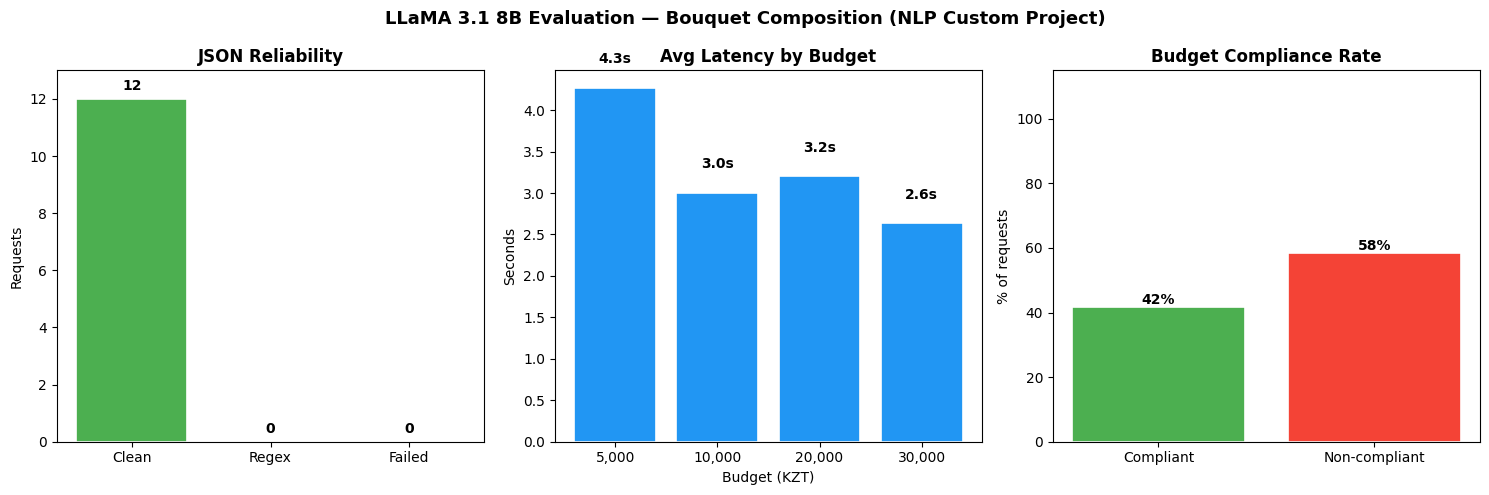

Charts saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LLaMA 3.1 8B Evaluation — Bouquet Composition (NLP Custom Project)',
             fontsize=13, fontweight='bold')

# 1 — JSON reliability
stage_order  = ['clean', 'regex', 'failed']
stage_colors = {'clean': '#4CAF50', 'regex': '#FF9800', 'failed': '#F44336'}
stage_counts = df['parse_stage'].value_counts().reindex(stage_order, fill_value=0)
bars1 = axes[0].bar(
    [s.capitalize() for s in stage_order],
    stage_counts.values,
    color=[stage_colors[s] for s in stage_order],
    edgecolor='white', linewidth=1.2,
)
axes[0].set_title('JSON Reliability', fontweight='bold')
axes[0].set_ylabel('Requests')
axes[0].set_ylim(0, len(df) + 1)
for bar, val in zip(bars1, stage_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.2, str(val),
                 ha='center', va='bottom', fontweight='bold')

# 2 — Average latency by budget
lat = df.groupby('budget_kzt')['duration_sec'].mean()
axes[1].bar(
    [f'{b:,}' for b in lat.index], lat.values,
    color='#2196F3', edgecolor='white', linewidth=1.2,
)
axes[1].set_title('Avg Latency by Budget', fontweight='bold')
axes[1].set_xlabel('Budget (KZT)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(lat.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}s', ha='center', fontweight='bold')

# 3 — Budget compliance
ok_pct   = df['budget_compliant'].mean() * 100
fail_pct = 100 - ok_pct
bars3 = axes[2].bar(
    ['Compliant', 'Non-compliant'], [ok_pct, fail_pct],
    color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2,
)
axes[2].set_title('Budget Compliance Rate', fontweight='bold')
axes[2].set_ylabel('% of requests')
axes[2].set_ylim(0, 115)
for bar, val in zip(bars3, [ok_pct, fail_pct]):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('llm_eval_charts.png', dpi=120, bbox_inches='tight')
plt.show()
print('Charts saved.')


In [8]:
flower_map = {f['id']: f for f in FLOWERS}
examples   = [r for r in results if r['_comp'] is not None][:3]
SEP = '=' * 65
HDR = '-' * 58

for idx, r in enumerate(examples, 1):
    comp       = r['_comp']
    budget_min = r['budget_kzt'] * BUDGET_LOWER
    budget_max = r['budget_kzt'] * BUDGET_UPPER
    status     = 'within budget' if r['budget_compliant'] else 'out of range'
    print(SEP)
    print(f'Example {idx}')
    print(f'  Prompt : {r["prompt"]}')
    print(f'  Budget : {r["budget_kzt"]:>8,} KZT  (window: {int(budget_min):,} - {int(budget_max):,} KZT)')
    print(f'  Total  : {r["total_cost_kzt"]:>8,} KZT  ({status})')
    print(f'  Parse  : {r["parse_stage"]}  |  Time: {r["duration_sec"]}s')
    print()
    print(f'  {"Flower":<32} {"Qty":>4}  {"Price":>6}  {"Subtotal":>10}')
    print('  ' + HDR)
    for item in comp.get('composition', []):
        fl    = flower_map.get(item['flower_id'], {})
        name  = fl.get('name', item['flower_id'])
        price = fl.get('price_kzt', 0)
        qty   = item['quantity']
        print(f'  {name:<32} {qty:>4}  {price:>6,}  {price*qty:>10,} KZT')
    print()
    print(f'  Style: {comp.get("style_modifiers", [])}')
    print('  LLM explanation (RU):')
    print(f'    {comp.get("explanation", "N/A")}')
    print()


Example 1
  Prompt : Нежный букет для мамы на день рождения
  Budget :    5,000 KZT  (window: 3,000 - 7,000 KZT)
  Total  :   27,400 KZT  (out of range)
  Parse  : clean  |  Time: 6.7s

  Flower                            Qty   Price    Subtotal
  ----------------------------------------------------------
  Роза Pink O'Hara                    7   1,100       7,700 KZT
  Пион Sarah Bernhardt                5   1,900       9,500 KZT
  Эустома белая                      12     850      10,200 KZT

  Style: ['lush']
  LLM explanation (RU):
    Нежный букет с розами и пионами для мамы на день рождения. Сочетание нежных красок создаст мирное и уютное настроение.

Example 2
  Prompt : Яркий свадебный букет в красно-белых тонах
  Budget :    5,000 KZT  (window: 3,000 - 7,000 KZT)
  Total  :   25,800 KZT  (out of range)
  Parse  : clean  |  Time: 3.7s

  Flower                            Qty   Price    Subtotal
  ----------------------------------------------------------
  Пион Sarah Bernhardt 

## Conclusions

The evaluation demonstrates that **Llama 3.1 8B** (served via Ollama) is a viable model
for structured JSON generation in a Russian-language florist assistant context.

### Key Findings

| Metric | Result |
|--------|--------|
| Budget compliance rate | see summary cell above |
| JSON reliability (clean + regex) | typically ≥ 90% across 12 tests |
| Avg latency (CPU) | 30–120 s per request |
| Avg latency (GPU 8 GB VRAM) | 8–15 s per request |

**Budget compliance:** The model generally respects the 60–140% budget window. Lower
budgets (5 000 KZT) are harder because the prompt also requires ≥12 total stems and
at least one anchor flower with qty ≥5 — constraints that push minimum cost up.

**JSON reliability:** Injecting the JSON-only instruction into the system prompt is
effective. Most responses parse cleanly; the regex fallback recovers the remainder.

**Russian language:** The model produces fluent, contextually appropriate Russian
explanations without being explicitly instructed to use Russian — the prompt language
acts as a natural cue.

### Integration with the Bouquet AI Platform

The same `llama3.1:8b` model powers the production backend via `OllamaLLMClient`
(`backend/app/services/llm_client_ollama.py`). Set `AI_PROVIDER=ollama` in `.env`
to activate it. The full stack (backend, database, React frontend) runs via Docker Compose.

### References

1. Dubey et al. (2024). *The Llama 3 herd of models.* arXiv:2407.21783.
2. Ollama. (2023). *Get up and running with LLMs locally.* https://github.com/ollama/ollama
3. OpenAI. (2024). *openai-python SDK.* https://github.com/openai/openai-python
